# 1. Import All Required Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset and Apply some Statistical Methods to Get a Basic Understanding of Dataset 

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
missing = df.isnull().mean()*100
missing[missing > 0]

name                  0.032723
host_name             0.042949
last_review          20.558339
reviews_per_month    20.558339
dtype: float64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## EDA - Create Visuals to Find Informative Insights

In [8]:
df["room_type"].value_counts(normalize=True)*100

room_type
Entire home/apt    51.966459
Private room       45.661111
Shared room         2.372431
Name: proportion, dtype: float64

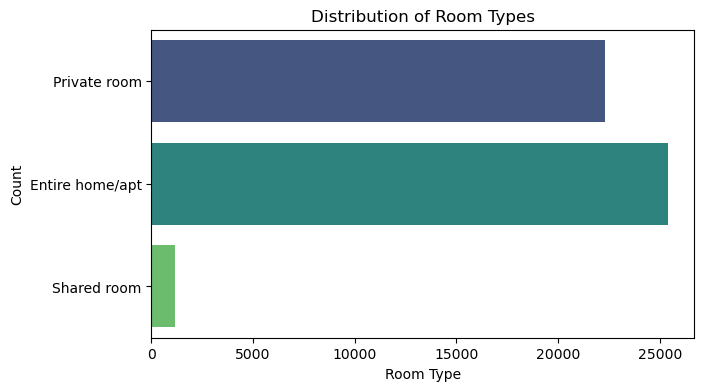

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(df["room_type"], palette='viridis')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()
plt.show()

In [10]:
df.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25409.0,211.794246,284.041611,0.0,120.0,160.0,229.0,10000.0
Private room,22326.0,89.780973,160.205262,0.0,50.0,70.0,95.0,10000.0
Shared room,1160.0,70.127586,101.725252,0.0,33.0,45.0,75.0,1800.0


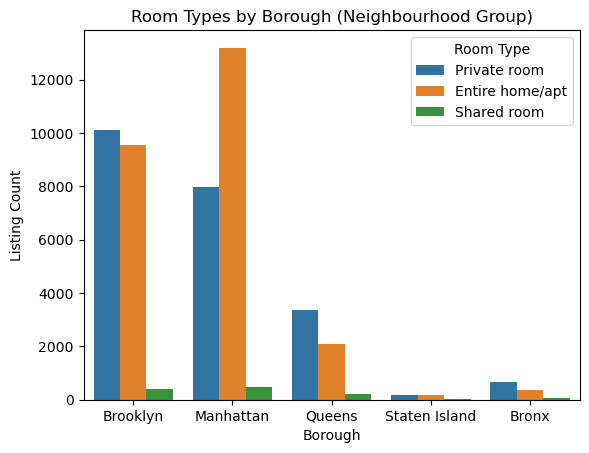

In [11]:
sns.countplot(data=df, x="neighbourhood_group", hue="room_type")
plt.title('Room Types by Borough (Neighbourhood Group)')
plt.xlabel('Borough')
plt.ylabel('Listing Count')
plt.legend(title='Room Type')
plt.show()

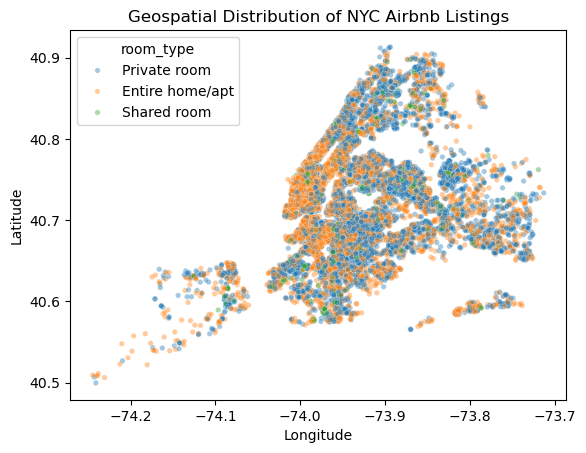

In [12]:
sns.scatterplot(data=df, x="longitude", y="latitude", hue="room_type", alpha=0.4, s=15)
plt.title('Geospatial Distribution of NYC Airbnb Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

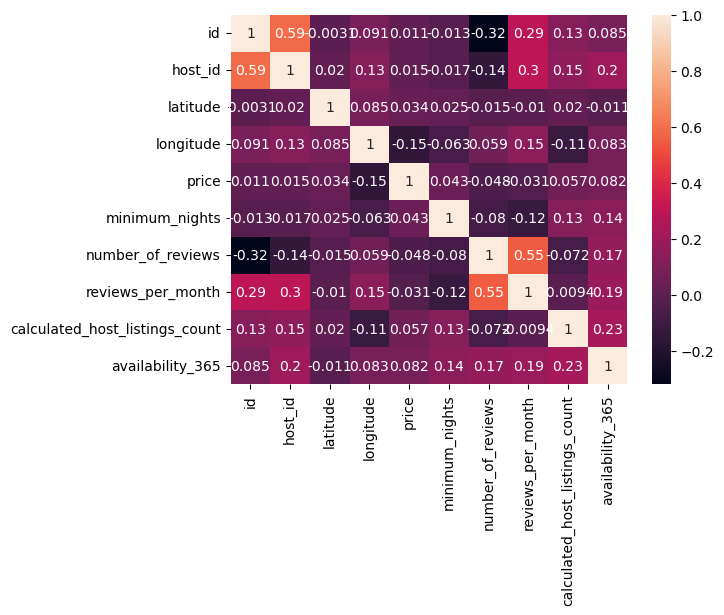

In [13]:
num_val = df.select_dtypes(include="number")
cor = num_val.corr()

sns.heatmap(cor, annot=True)
plt.show()

# Preprocessing and Date Cleaning

### Drop Unnecessary Columns

In [14]:
# Drop Ueless Columns
df_clean = df.drop(['id','name', 'host_id', 'host_name', 'last_review'], axis=1)
df_clean.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365


In [15]:
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

### Remove Outliers using IQR

In [16]:
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


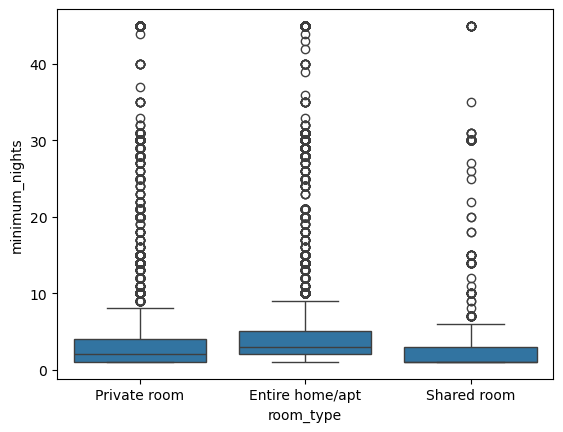

In [17]:
sns.boxplot(x='room_type', y='minimum_nights', data=df_clean)
plt.show()

### Split Data into 2 parts Traning and Testing

In [18]:
x = df_clean.drop('room_type', axis=1)
y = df_clean['room_type']

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Create Pipeline and Add Transformation Tecknicks

In [20]:
# imports For Creating Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

# Imports For Model Building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [21]:
cat_features = ['neighbourhood_group', 'neighbourhood']
num_features = df_clean.select_dtypes(include="number").columns.tolist()

In [22]:
numaric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy="median")),
    # ('skewness', PowerTransformer(method="yeo-johnson")),
    ('scale', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numaric', numaric_pipeline, num_features),
    ('categorical', categorical_pipeline, cat_features)
])

In [24]:
# class_weight="Balanced" tells the model to pay more attention to the minority class or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is.

models = {
    "Logistic_Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Decision_Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random_Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient_Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    accuracy_score = cross_val_score(pipeline, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    f1_macro_score = cross_val_score(pipeline, x_train, y_train, cv=3, scoring='f1_macro', n_jobs=-1)

    print(f"{name} Accuracy Score: {accuracy_score.mean()}, F1 Macro Score: {f1_macro_score.mean()}")


### Select Final model and apply Hyperperametor Tuning 

In [25]:
from sklearn.model_selection import GridSearchCV

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100,200,300,400],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10]
    # 'classifier__min_samples_leaf': [1, 2, 4]
}

search = GridSearchCV(best_pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
search.fit(x_train, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best Score: {search.best_score_}")

Best Parameters: {'classifier__max_depth': 30, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 400}
Best Score: 0.7381120559918158


### Understand the model Purformance using confusion_matrix, classification_report

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

best_pipeline = search.best_estimator_ 

y_pred = best_pipeline.predict(x_test)
print("confusion_matrix:", confusion_matrix(y_test, y_pred))
print("classification_report:", classification_report(y_test, y_pred))

confusion_matrix: [[4459  623    0]
 [ 624 3824   17]
 [  21  119   92]]
classification_report:                  precision    recall  f1-score   support

Entire home/apt       0.87      0.88      0.88      5082
   Private room       0.84      0.86      0.85      4465
    Shared room       0.84      0.40      0.54       232

       accuracy                           0.86      9779
      macro avg       0.85      0.71      0.75      9779
   weighted avg       0.86      0.86      0.85      9779



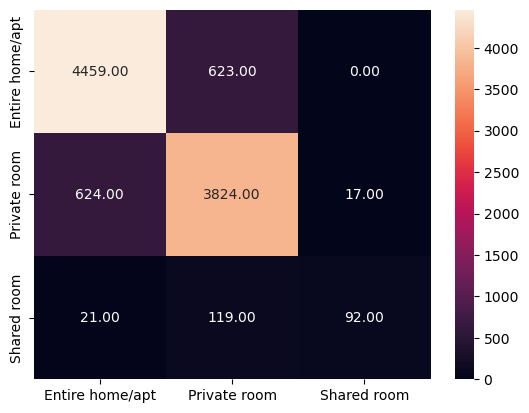

In [34]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f", xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
plt.show()

### Save Final Model 

In [35]:
import joblib

joblib.dump(best_pipeline, "model_pipeline.pkl")

['model_pipeline.pkl']